# Cinemática y volumen de la CME halo — Evento 1 (17/12/2024)

**Tesis:** Cálculo cinemático y estimación volumétrica de CMEs tipo halo con SunPy · **Avance para el asesor**

Este es el **tercer paso del flujo de trabajo**:

| Paso | Cuaderno |
|---|---|
| 1. Descargar los FITS de LASCO C2 y C3 | `01_descargar_evento1.ipynb` |
| 2. Procesar las imágenes y construir el diagrama altura-tiempo (h-t) | `02_procesar_evento1.ipynb` (automático) y `03_grafica_manual_evento1.ipynb` (manual) |
| **3. Cinemática (velocidad, aceleración) y volumen esférico** | **este cuaderno** |

**Qué hace (ejecutar de arriba hacia abajo con Shift + Enter):**
1. Lee la tabla h-t (manual, automática o ambas). Si no encuentra ningún archivo, usa la serie manual del evento incluida en el cuaderno, así que **corre sin necesitar nada más**.
2. Ajusta un modelo **lineal** (velocidad constante) y uno **cuadrático** (aceleración constante) por mínimos cuadrados ponderados, con incertidumbres.
3. Calcula el **volumen** asumiendo un modelo esférico, $V = \frac{2\pi}{3} R^3 (1-\cos\theta)$ con $\theta = W/2$, que para un halo completo ($W = 360^\circ$) se reduce a la esfera $V = \frac{4\pi}{3} R^3$.
4. Genera tres figuras y tablas listas para las diapositivas.

> **Estado: primer avance.** Es una primera aproximación transparente y reproducible, pensada para revisarla con especialistas. Las limitaciones conocidas están al final del cuaderno y conviene mencionarlas al presentarlo.

## 1. Importaciones

In [1]:
%matplotlib inline
import csv                                   # lectura y escritura de tablas CSV
import io                                    # para leer texto como si fuera un archivo (datos de respaldo)
from datetime import datetime, timedelta     # manejo de fechas, horas e intervalos de tiempo
from pathlib import Path                     # rutas de archivos que funcionan igual en Windows, Linux y Mac
import numpy as np                           # cálculo numérico con arreglos
import matplotlib.pyplot as plt              # gráficos
import matplotlib.dates as mdates            # formato de horas en los ejes
from scipy.optimize import curve_fit         # ajuste de curvas por mínimos cuadrados (con pesos)
from astropy import units as u               # unidades físicas (km, m, s, UA, R_sun)
from astropy import constants as const       # constantes físicas (radio solar, UA)

## 2. Parámetros

**Qué cambiar aquí:**
- `FUENTE_PRINCIPAL`: qué serie h-t usar para las figuras y el resumen (`"manual"` o `"automatico"`).
- `ANCHO_ANGULAR_DEG`: ancho angular del catálogo CDAW. Para un halo completo es 360°.
- `V_CATALOGO_KMS`: velocidad lineal del catálogo CDAW para este evento (déjala en `None` si no la tienes; si la escribes, se compara con tus resultados).

In [2]:
FUENTE_PRINCIPAL = "manual"                  # serie h-t principal: "manual" (14 puntos hasta las 18:30) o "automatico" (salida del cuaderno 02)

# Dónde buscar las tablas h-t (se usa la primera ruta que exista); si no hay ninguna, se usan los datos de respaldo
RUTAS = {"manual": [Path("ht_manual_evento1.csv"), Path("resultados_evento1/ht_manual_evento1.csv")],
         "automatico": [Path("resultados_evento1/ht_evento1.csv"), Path("ht_evento1.csv")]}

ANCHO_ANGULAR_DEG = 360.0                    # ancho angular W del catálogo CDAW (halo completo = 360°)
MPA_CATALOGO_DEG = 177.0                     # ángulo de posición central (MPA) del catálogo; el sector medido fue PA = 178° ± 3°
V_CATALOGO_KMS = None                        # velocidad lineal del catálogo CDAW en km/s (por ejemplo 1500); None = no comparar

CARPETA_SALIDA = Path("resultados_evento1")  # aquí se guardan las figuras y tablas de este cuaderno
CARPETA_SALIDA.mkdir(exist_ok=True)          # se crea si no existe
print("Los resultados se guardarán en:", CARPETA_SALIDA.resolve())

Los resultados se guardarán en: C:\Users\Steve\Aprendiendo Python\resultados_evento1


## 3. Constantes físicas

Se usan las constantes de `astropy` (radio solar nominal de la IAU = 695 700 km; 1 UA = 149 597 870.7 km).

In [3]:
R_SUN_KM = const.R_sun.to(u.km).value        # radio solar en km (695 700 km)
R_SUN_M = const.R_sun.to(u.m).value          # radio solar en m
UA_M = const.au.to(u.m).value                # 1 unidad astronómica en m
print(f"R_sun = {R_SUN_KM:,.0f} km | 1 UA = {UA_M:.6e} m")

R_sun = 695,700 km | 1 UA = 1.495979e+11 m


## 4. Lectura de la tabla altura-tiempo

Cada serie tiene: hora (UT), detector, altura proyectada del frente (en R☉) y su incertidumbre (en R☉).
Si no se encuentra ningún archivo, se usan los **datos de respaldo**: los 14 puntos del método manual (obtenidos con `03_grafica_manual_evento1.ipynb`).

In [4]:
# --- Datos de respaldo: serie manual del evento 1 (salida de 03_grafica_manual_evento1.ipynb) ---
DATOS_RESPALDO = """tiempo_utc,detector,altura_rsun,sigma_rsun
2024-12-17 16:00:05,C2,2.985,0.049
2024-12-17 16:12:05,C2,5.883,0.049
2024-12-17 16:18:06,C3,7.154,0.23
2024-12-17 16:30:05,C3,9.334,0.23
2024-12-17 16:42:05,C3,11.746,0.23
2024-12-17 16:54:05,C3,13.707,0.23
2024-12-17 17:06:05,C3,15.58,0.23
2024-12-17 17:18:05,C3,17.291,0.23
2024-12-17 17:30:06,C3,19.12,0.23
2024-12-17 17:42:05,C3,20.509,0.23
2024-12-17 17:54:05,C3,22.365,0.23
2024-12-17 18:06:05,C3,23.993,0.23
2024-12-17 18:18:06,C3,25.863,0.23
2024-12-17 18:30:05,C3,27.246,0.23
"""

def leer_ht(texto_csv):
    """Convierte el texto de una tabla h-t en un diccionario de arreglos ordenados por hora."""
    filas = list(csv.DictReader(io.StringIO(texto_csv)))                       # lee cada fila como diccionario
    filas.sort(key=lambda f: f["tiempo_utc"])                                  # ordena por hora
    return dict(
        t=np.array([datetime.strptime(f["tiempo_utc"], "%Y-%m-%d %H:%M:%S") for f in filas]),   # horas (objetos datetime)
        det=np.array([f["detector"] for f in filas]),                          # detector de cada punto (C2 o C3)
        h=np.array([float(f["altura_rsun"]) for f in filas]),                  # altura proyectada del frente (R_sun)
        s=np.array([float(f["sigma_rsun"]) for f in filas]))                   # incertidumbre de la altura (R_sun)

series = {}                                                                    # aquí se guardan las series encontradas
for nombre, rutas in RUTAS.items():                                            # busca la serie manual y la automática
    ruta = next((r for r in rutas if r.exists()), None)                        # primera ruta que exista
    if ruta is not None:
        series[nombre] = leer_ht(ruta.read_text(encoding="utf-8"))
        print(f"Serie '{nombre}': {len(series[nombre]['h'])} puntos leídos de {ruta}")
if not series:                                                                 # si no hay ninguna tabla, se usan los datos de respaldo
    series["manual"] = leer_ht(DATOS_RESPALDO)
    print(f"No se encontraron tablas h-t. Se usan los datos de respaldo (serie manual, {len(series['manual']['h'])} puntos).")
if FUENTE_PRINCIPAL not in series:                                             # si la serie pedida no existe, se usa la primera disponible
    FUENTE_PRINCIPAL = next(iter(series))
    print(f"La fuente principal solicitada no existe; se usa '{FUENTE_PRINCIPAL}'.")
print("Fuente principal:", FUENTE_PRINCIPAL)

Serie 'manual': 14 puntos leídos de ht_manual_evento1.csv
Serie 'automatico': 7 puntos leídos de resultados_evento1\ht_evento1.csv
Fuente principal: manual


## 5. Ajuste cinemático

Con la altura $h$ en km y el tiempo $t$ en segundos desde el primer punto:

- **Lineal:** $h(t) = h_0 + v\,t$ → velocidad media constante $v$.
- **Cuadrático:** $h(t) = h_0 + v_0\,t + \tfrac{1}{2}\,a\,t^2$ → velocidad inicial $v_0$ y aceleración constante $a$ (negativa = desaceleración).

El ajuste es por **mínimos cuadrados ponderados** (cada punto pesa según su incertidumbre). Se reporta $\chi^2_\nu$ (chi-cuadrado reducido; cerca de 1 indica un buen ajuste, mucho mayor sugiere que el modelo o las incertidumbres no bastan) y el criterio **BIC** para comparar los dos modelos (menor es mejor; una diferencia mayor a 10 es una preferencia fuerte).

In [5]:
def ajustar(serie):
    """Ajusta los modelos lineal y cuadrático a una serie h-t. Devuelve un diccionario con resultados."""
    t0 = serie["t"][0]                                                         # el tiempo cero es el primer punto
    t = np.array([(x - t0).total_seconds() for x in serie["t"]])               # tiempo en segundos desde el primer punto
    h = serie["h"] * R_SUN_KM                                                  # altura en km
    s = serie["s"] * R_SUN_KM                                                  # incertidumbre en km

    lineal = lambda t, h0, v: h0 + v * t                                       # modelo lineal
    cuadratico = lambda t, h0, v0, a: h0 + v0 * t + 0.5 * a * t ** 2           # modelo cuadrático
    res = dict(t0=t0, t=t, h=h, s=s)                                           # se guardan los datos de entrada

    for nombre, f, grado in [("lineal", lineal, 1), ("cuadratico", cuadratico, 2)]:
        n_par = grado + 1                                                      # nº de parámetros del modelo
        if len(t) <= n_par:                                                    # con muy pocos puntos no se puede ajustar
            continue
        p0 = np.polyfit(t, h, grado)[::-1]                                     # estimación inicial (mínimos cuadrados simples)
        popt, pcov = curve_fit(f, t, h, p0=p0, sigma=s, absolute_sigma=True)   # ajuste ponderado
        resid = h - f(t, *popt)                                                # residuos (km)
        chi2 = float(np.sum((resid / s) ** 2))                                 # chi-cuadrado
        gl = len(t) - n_par                                                    # grados de libertad
        chi2_red = chi2 / gl                                                   # chi-cuadrado reducido
        err = np.sqrt(np.diag(pcov))                                           # incertidumbres formales de los parámetros
        err_esc = err * np.sqrt(max(chi2_red, 1.0))                            # incertidumbres reescaladas por chi2_red (más realistas si chi2_red > 1)
        bic = chi2 + n_par * np.log(len(t))                                    # criterio de información bayesiano
        res[nombre] = dict(f=f, popt=popt, pcov=pcov, err=err, err_esc=err_esc,
                           chi2=chi2, chi2_red=chi2_red, gl=gl, bic=bic, resid=resid)
    return res

def velocidad_en(res, tiempo_s):
    """Velocidad del ajuste cuadrático en el instante tiempo_s (s) y su incertidumbre (propagada con la covarianza y reescalada por chi2_red)."""
    (h0, v0, a), cov = res["cuadratico"]["popt"], res["cuadratico"]["pcov"]    # parámetros y covarianza
    v = v0 + a * tiempo_s                                                      # v(t) = v0 + a t
    var = cov[1, 1] + tiempo_s ** 2 * cov[2, 2] + 2 * tiempo_s * cov[1, 2]     # varianza formal de v(t)
    return v, np.sqrt(var) * np.sqrt(max(res["cuadratico"]["chi2_red"], 1.0))  # incertidumbre reescalada igual que la de los parámetros

ajustes = {nombre: ajustar(serie) for nombre, serie in series.items()}         # ajusta cada serie disponible

### 5.1 Resultados del ajuste

In [6]:
def imprimir_resultados(nombre, res):
    """Imprime una tabla legible con los parámetros de ambos modelos."""
    print(f"\n===== Serie '{nombre}' ({len(res['t'])} puntos) =====")
    L, Q = res["lineal"], res["cuadratico"]
    print(f"Lineal     : v = {L['popt'][1]:8.1f} ± {L['err_esc'][1]:5.1f} km/s              | chi2_red = {L['chi2_red']:6.2f} | BIC = {L['bic']:8.1f}")
    print(f"Cuadrático : v0 = {Q['popt'][1]:8.1f} ± {Q['err_esc'][1]:5.1f} km/s, a = {Q['popt'][2] * 1e3:7.1f} ± {Q['err_esc'][2] * 1e3:5.1f} m/s² | chi2_red = {Q['chi2_red']:6.2f} | BIC = {Q['bic']:8.1f}")
    v_fin, e_fin = velocidad_en(res, res["t"][-1])                             # velocidad al final del intervalo observado
    print(f"Velocidad del ajuste cuadrático al final ({res['t'][-1] / 3600:.1f} h): {v_fin:.0f} ± {e_fin:.0f} km/s")
    d_bic = L["bic"] - Q["bic"]                                                # diferencia de BIC entre modelos
    preferido = "cuadrático (con aceleración)" if d_bic > 10 else ("lineal" if d_bic < -10 else "ninguno claramente")
    print(f"ΔBIC (lineal - cuadrático) = {d_bic:.1f}  ->  modelo preferido: {preferido}")
    if V_CATALOGO_KMS is not None:                                             # comparación con el catálogo si se dio su velocidad
        print(f"Velocidad lineal del catálogo CDAW = {V_CATALOGO_KMS:.0f} km/s  (diferencia con el ajuste lineal: {L['popt'][1] - V_CATALOGO_KMS:+.0f} km/s)")

for nombre, res in ajustes.items():
    imprimir_resultados(nombre, res)
print("\nNota: las incertidumbres se reescalaron por sqrt(chi2_red) cuando chi2_red > 1 (las alturas marcadas tienen errores subestimados o el modelo es simple).")


===== Serie 'manual' (14 puntos) =====
Lineal     : v =   1942.2 ±  49.7 km/s              | chi2_red =  27.66 | BIC =    337.2
Cuadrático : v0 =   2508.7 ±  74.7 km/s, a =  -152.1 ±  19.3 m/s² | chi2_red =   4.55 | BIC =     57.9
Velocidad del ajuste cuadrático al final (2.5 h): 1140 ± 104 km/s
ΔBIC (lineal - cuadrático) = 279.3  ->  modelo preferido: cuadrático (con aceleración)

===== Serie 'automatico' (7 puntos) =====
Lineal     : v =   2207.6 ±  64.6 km/s              | chi2_red =   2.47 | BIC =     16.3
Cuadrático : v0 =   2615.8 ± 127.9 km/s, a =  -238.9 ±  70.9 m/s² | chi2_red =   0.25 | BIC =      6.9
Velocidad del ajuste cuadrático al final (1.1 h): 1670 ± 165 km/s
ΔBIC (lineal - cuadrático) = 9.4  ->  modelo preferido: ninguno claramente

Nota: las incertidumbres se reescalaron por sqrt(chi2_red) cuando chi2_red > 1 (las alturas marcadas tienen errores subestimados o el modelo es simple).


### 5.2 Figura 1: diagrama altura-tiempo con los ajustes y los residuos

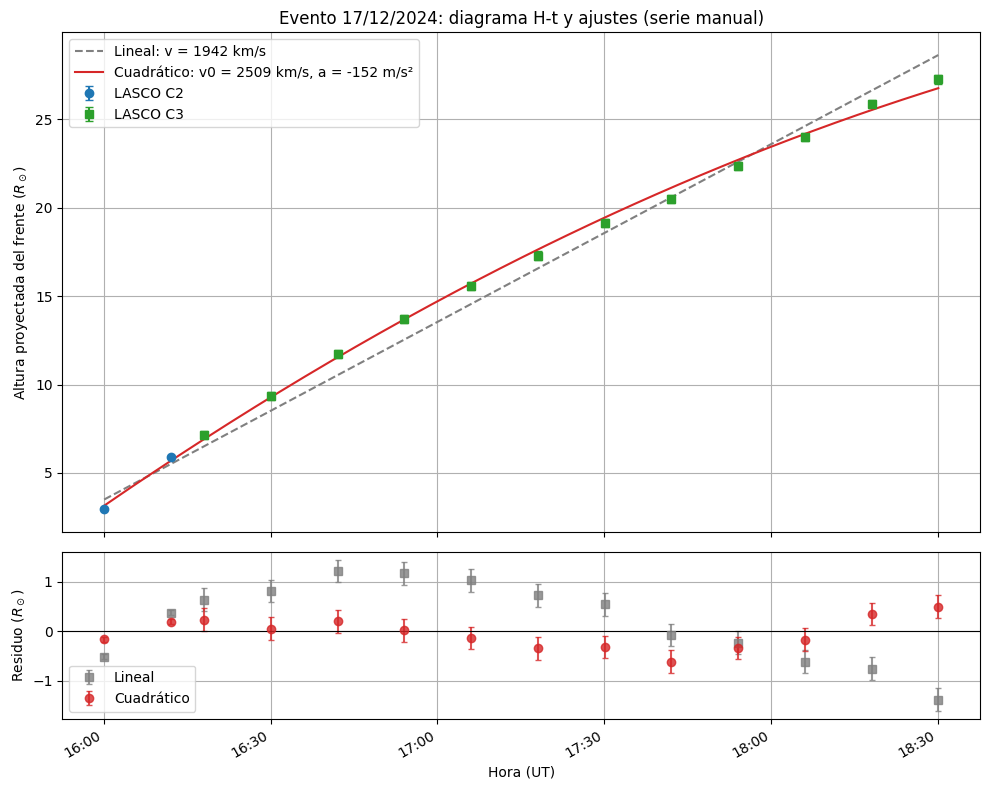

In [7]:
res = ajustes[FUENTE_PRINCIPAL]; serie = series[FUENTE_PRINCIPAL]              # serie y ajuste principales
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})   # panel principal y de residuos
t_fino = np.linspace(res["t"][0], res["t"][-1], 300)                           # tiempos finos para dibujar las curvas
horas_finas = [res["t0"] + timedelta(seconds=float(x)) for x in t_fino]   # tiempos finos como fechas
for det, marcador, color in [("C2", "o", "tab:blue"), ("C3", "s", "tab:green")]:   # cada detector con su estilo
    m = serie["det"] == det                                                    # puntos de este detector
    if m.any():
        ax1.errorbar(serie["t"][m], serie["h"][m], yerr=serie["s"][m], fmt=marcador, color=color, capsize=3, label=f"LASCO {det}")   # datos con barras de error
ax1.plot(horas_finas, res["lineal"]["f"](t_fino, *res["lineal"]["popt"]) / R_SUN_KM, "--", color="gray",
         label=f"Lineal: v = {res['lineal']['popt'][1]:.0f} km/s")             # ajuste lineal
ax1.plot(horas_finas, res["cuadratico"]["f"](t_fino, *res["cuadratico"]["popt"]) / R_SUN_KM, "-", color="tab:red",
         label=f"Cuadrático: v0 = {res['cuadratico']['popt'][1]:.0f} km/s, a = {res['cuadratico']['popt'][2] * 1e3:.0f} m/s²")   # ajuste cuadrático
ax1.set_ylabel(r"Altura proyectada del frente ($R_\odot$)")                    # eje y
ax1.set_title(f"Evento 17/12/2024: diagrama H-t y ajustes (serie {FUENTE_PRINCIPAL})")   # título
ax1.grid(True); ax1.legend()                                                   # cuadrícula y leyenda
for etiqueta, clave, color, estilo in [("Lineal", "lineal", "gray", "s"), ("Cuadrático", "cuadratico", "tab:red", "o")]:   # residuos de ambos modelos
    ax2.errorbar(serie["t"], res[clave]["resid"] / R_SUN_KM, yerr=serie["s"], fmt=estilo, color=color, capsize=2, alpha=0.8, label=etiqueta)
ax2.axhline(0, color="k", lw=0.8)                                              # línea de residuo cero
ax2.set_ylabel(r"Residuo ($R_\odot$)"); ax2.set_xlabel("Hora (UT)")            # etiquetas del panel de residuos
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))                   # horas como HH:MM
ax2.grid(True); ax2.legend()                                                   # cuadrícula y leyenda
fig.autofmt_xdate(); fig.tight_layout()                                        # acomoda las etiquetas
fig.savefig(CARPETA_SALIDA / "fig1_ht_ajustes.png", dpi=150)                   # guarda la figura
plt.show()                                                                     # la muestra en el cuaderno

### 5.3 Figura 2: velocidad en función del tiempo

Los puntos son velocidades entre puntos consecutivos, $\Delta h / \Delta t$ (**sin ajuste**): muestran directamente si la CME se frena. La línea roja es la velocidad del ajuste cuadrático.

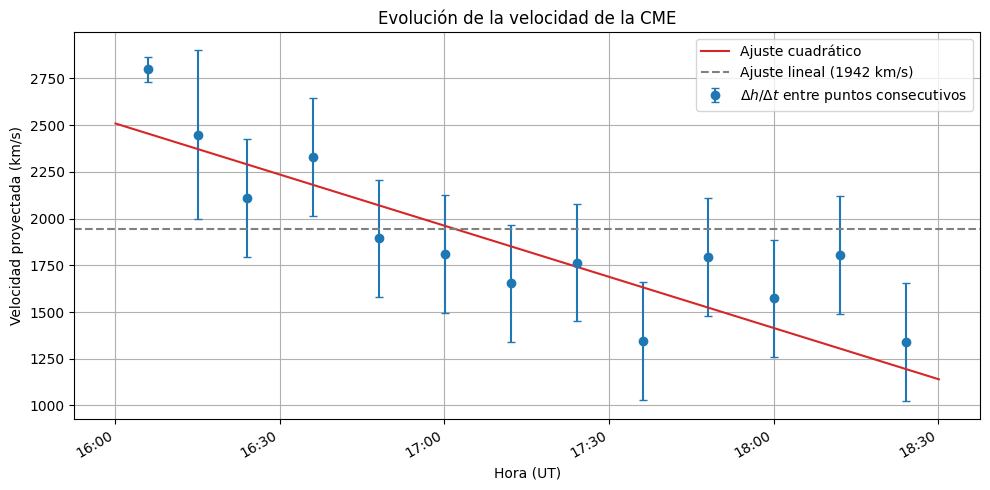

In [8]:
t = res["t"]; h = res["h"]; s = res["s"]                                       # tiempos (s), alturas (km) e incertidumbres (km)
v_dif = np.diff(h) / np.diff(t)                                                # velocidad entre puntos consecutivos (km/s)
e_dif = np.sqrt(s[1:] ** 2 + s[:-1] ** 2) / np.diff(t)                         # su incertidumbre (km/s)
t_medio = 0.5 * (t[1:] + t[:-1])                                               # instante medio de cada intervalo (s)
horas_medias = [res["t0"] + timedelta(seconds=float(x)) for x in t_medio]   # instantes medios como fechas
v_ajuste = res["cuadratico"]["popt"][1] + res["cuadratico"]["popt"][2] * t_fino   # v(t) del ajuste cuadrático

fig, ax = plt.subplots(figsize=(10, 5))                                        # figura de la velocidad
ax.errorbar(horas_medias, v_dif, yerr=e_dif, fmt="o", color="tab:blue", capsize=3, label=r"$\Delta h/\Delta t$ entre puntos consecutivos")   # velocidades directas
ax.plot(horas_finas, v_ajuste, "-", color="tab:red", label="Ajuste cuadrático")   # velocidad del ajuste
ax.axhline(res["lineal"]["popt"][1], ls="--", color="gray", label=f"Ajuste lineal ({res['lineal']['popt'][1]:.0f} km/s)")   # velocidad lineal
if V_CATALOGO_KMS is not None:                                                 # velocidad del catálogo si se dio
    ax.axhline(V_CATALOGO_KMS, ls=":", color="tab:green", label=f"Catálogo CDAW ({V_CATALOGO_KMS:.0f} km/s)")
ax.set_xlabel("Hora (UT)"); ax.set_ylabel("Velocidad proyectada (km/s)")       # etiquetas
ax.set_title("Evolución de la velocidad de la CME")                            # título
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))                    # horas como HH:MM
ax.grid(True); ax.legend(); fig.autofmt_xdate(); fig.tight_layout()            # detalles
fig.savefig(CARPETA_SALIDA / "fig2_velocidad.png", dpi=150)                    # guarda la figura
plt.show()                                                                     # la muestra en el cuaderno

## 6. Volumen con el modelo esférico

**Modelo del proyecto (pedido por el asesor):**
$$V(t) = \frac{2\pi}{3}\,R^3(t)\,\left(1-\cos\theta\right),\qquad \theta = \frac{W}{2}$$
con $R(t)$ la altura del frente medida desde el centro del Sol y $W$ el ancho angular del catálogo. Para un halo completo ($W=360^\circ$, $\theta=180^\circ$) queda $V=\frac{4\pi}{3}R^3$.

**Cómo interpretarlo:** este modelo es un *sector esférico con vértice en el centro del Sol*, así que incluye **todo** el volumen desde el Sol hasta el frente. La CME real ocupa mucho menos, por lo que el resultado es un **límite superior** del volumen.

**Referencia inferior (opcional, no es parte del proyecto):** una esfera adosada a la superficie del Sol, con su borde delantero en $R$: radio $r=(R-R_\odot)/2$ y $V=\frac{4\pi}{3}r^3$. Sirve solo para acotar la incertidumbre del modelo: el volumen real estaría entre ambos valores.

La incertidumbre propaga el error de la altura: $\sigma_V = 3\,V\,\sigma_R/R$.

In [9]:
def volumen_sector(h_rsun, ancho_deg):
    """Volumen (m^3) del sector esférico con vértice en el Sol y frente a la altura h (en R_sun)."""
    R = np.asarray(h_rsun) * R_SUN_M                                           # radio del frente en metros
    theta = np.radians(ancho_deg / 2.0)                                        # semiángulo de apertura
    return (2.0 * np.pi / 3.0) * R ** 3 * (1.0 - np.cos(theta))                # V = (2π/3) R³ (1 - cos θ)

def volumen_esfera_adosada(h_rsun):
    """Volumen (m^3) de una esfera adosada al Sol con borde delantero a la altura h (referencia inferior)."""
    r = (np.asarray(h_rsun) - 1.0) / 2.0 * R_SUN_M                             # radio de la esfera: (R - R_sun) / 2
    return (4.0 * np.pi / 3.0) * r ** 3                                        # V = (4π/3) r³

h_r = serie["h"]; s_r = serie["s"]                                             # alturas e incertidumbres en R_sun
V_sup = volumen_sector(h_r, ANCHO_ANGULAR_DEG)                                 # volumen del modelo del proyecto (límite superior)
V_sup_err = 3.0 * V_sup * s_r / h_r                                            # incertidumbre propagada
V_inf = volumen_esfera_adosada(h_r)                                            # referencia inferior

print(f"{'Hora UT':<10}{'Det.':<6}{'H (R_sun)':>10}{'V sector (m^3)':>18}{'V sector (UA^3)':>18}{'V esf. adosada (m^3)':>22}")
for i in range(len(h_r)):                                                      # tabla del volumen en cada instante medido
    print(f"{serie['t'][i]:%H:%M:%S}  {serie['det'][i]:<6}{h_r[i]:>10.2f}{V_sup[i]:>18.3e}{V_sup[i] / UA_M ** 3:>18.3e}{V_inf[i]:>22.3e}")

Hora UT   Det.   H (R_sun)    V sector (m^3)   V sector (UA^3)  V esf. adosada (m^3)
16:00:05  C2          2.98         3.751e+28         1.120e-05             1.379e+27
16:12:05  C2          5.88         2.872e+29         8.578e-05             2.053e+28
16:18:06  C3          7.15         5.164e+29         1.543e-04             4.109e+28
16:30:05  C3          9.33         1.147e+30         3.426e-04             1.021e+29
16:42:05  C3         11.75         2.286e+30         6.827e-04             2.188e+29
16:54:05  C3         13.71         3.632e+30         1.085e-03             3.617e+29
17:06:05  C3         15.58         5.334e+30         1.593e-03             5.464e+29
17:18:05  C3         17.29         7.291e+30         2.178e-03             7.623e+29
17:30:06  C3         19.12         9.859e+30         2.945e-03             1.049e+30
17:42:05  C3         20.51         1.217e+31         3.634e-03             1.309e+30
17:54:05  C3         22.36         1.578e+31         4.713e-03   

### 6.1 Figura 3: volumen en función del tiempo

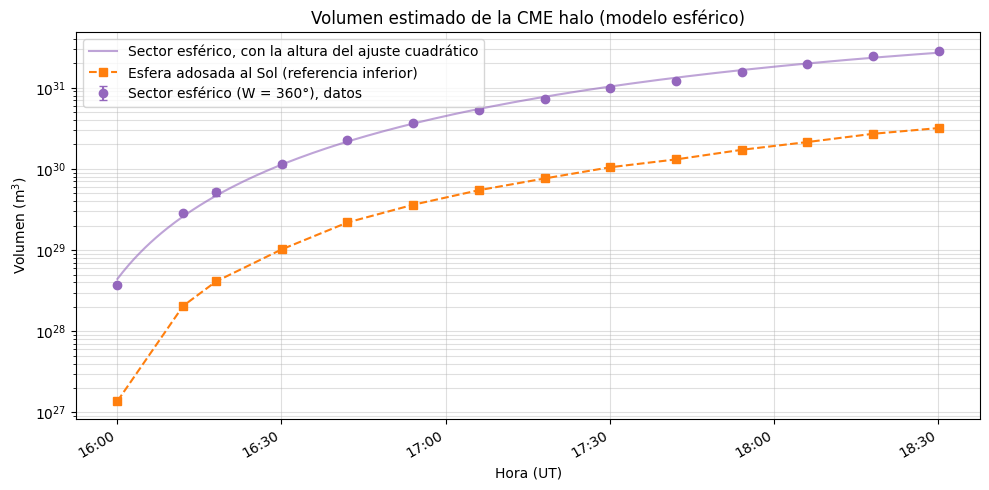

In [10]:
h_ajuste = res["cuadratico"]["f"](t_fino, *res["cuadratico"]["popt"]) / R_SUN_KM   # altura del ajuste cuadrático (R_sun)
fig, ax = plt.subplots(figsize=(10, 5))                                        # figura del volumen
ax.errorbar(serie["t"], V_sup, yerr=V_sup_err, fmt="o", color="tab:purple", capsize=3, label=f"Sector esférico (W = {ANCHO_ANGULAR_DEG:.0f}°), datos")   # datos del modelo del proyecto
ax.plot(horas_finas, volumen_sector(h_ajuste, ANCHO_ANGULAR_DEG), "-", color="tab:purple", alpha=0.6, label="Sector esférico, con la altura del ajuste cuadrático")   # curva suave
ax.plot(serie["t"], V_inf, "s--", color="tab:orange", label="Esfera adosada al Sol (referencia inferior)")   # referencia inferior
ax.set_yscale("log")                                                           # escala logarítmica: el volumen crece como R³
ax.set_xlabel("Hora (UT)"); ax.set_ylabel(r"Volumen ($\mathrm{m}^3$)")         # etiquetas
ax.set_title("Volumen estimado de la CME halo (modelo esférico)")              # título
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))                    # horas como HH:MM
ax.grid(True, which="both", alpha=0.4); ax.legend(); fig.autofmt_xdate(); fig.tight_layout()   # detalles
fig.savefig(CARPETA_SALIDA / "fig3_volumen.png", dpi=150)                      # guarda la figura
plt.show()                                                                     # la muestra en el cuaderno

## 7. Resumen del avance y archivos de salida

In [11]:
L, Q = res["lineal"], res["cuadratico"]                                        # ajustes de la serie principal
v_ini, e_ini = velocidad_en(res, 0.0); v_fin, e_fin = velocidad_en(res, res["t"][-1])   # velocidad inicial y final del ajuste cuadrático
i = -1                                                                         # último punto = máxima expansión observada
print("=" * 78)
print(f"RESUMEN — Evento 17/12/2024 — serie '{FUENTE_PRINCIPAL}' ({len(t)} puntos, {serie['t'][0]:%H:%M} a {serie['t'][-1]:%H:%M} UT)")
print("=" * 78)
print(f"Dirección de propagación (estimada)   : PA ≈ {MPA_CATALOGO_DEG:.0f}° (MPA del catálogo); ancho angular W = {ANCHO_ANGULAR_DEG:.0f}° (halo)")
print(f"Velocidad media (ajuste lineal)       : {L['popt'][1]:.0f} ± {L['err_esc'][1]:.0f} km/s")
print(f"Velocidad inicial (ajuste cuadrático) : {v_ini:.0f} ± {e_ini:.0f} km/s")
print(f"Velocidad final   (ajuste cuadrático) : {v_fin:.0f} ± {e_fin:.0f} km/s")
print(f"Aceleración (ajuste cuadrático)       : {Q['popt'][2] * 1e3:.0f} ± {Q['err_esc'][2] * 1e3:.0f} m/s²  ({'desaceleración' if Q['popt'][2] < 0 else 'aceleración'})")
print(f"Altura máxima observada               : {h_r[i]:.1f} R_sun ({serie['t'][i]:%H:%M} UT)")
print(f"Volumen (sector esférico, lím. superior): {V_sup[i]:.2e} ± {V_sup_err[i]:.1e} m^3 = {V_sup[i] / UA_M ** 3:.2e} UA^3")
print(f"Volumen (esfera adosada, ref. inferior) : {V_inf[i]:.2e} m^3 = {V_inf[i] / UA_M ** 3:.2e} UA^3")
print("=" * 78)

# --- Guardar tablas ---
with open(CARPETA_SALIDA / "volumen_evento1.csv", "w", newline="", encoding="utf-8") as f:   # volumen en cada instante
    w = csv.writer(f); w.writerow(["tiempo_utc", "detector", "altura_rsun", "V_sector_m3", "V_sector_err_m3", "V_sector_UA3", "V_esfera_adosada_m3"])
    for k in range(len(h_r)):
        w.writerow([f"{serie['t'][k]:%Y-%m-%d %H:%M:%S}", serie["det"][k], f"{h_r[k]:.3f}", f"{V_sup[k]:.4e}", f"{V_sup_err[k]:.3e}", f"{V_sup[k] / UA_M ** 3:.4e}", f"{V_inf[k]:.4e}"])
with open(CARPETA_SALIDA / "cinematica_evento1.csv", "w", newline="", encoding="utf-8") as f:   # parámetros de los ajustes de cada serie
    w = csv.writer(f); w.writerow(["serie", "modelo", "parametro", "valor", "error_reescalado", "unidad", "chi2_red", "BIC"])
    for nombre, r in ajustes.items():
        for modelo, pars in [("lineal", [("h0", 1, "km"), ("v", 1, "km/s")]), ("cuadratico", [("h0", 1, "km"), ("v0", 1, "km/s"), ("a", 1e3, "m/s2")])]:
            for j, (par, factor, unidad) in enumerate(pars):
                w.writerow([nombre, modelo, par, f"{r[modelo]['popt'][j] * factor:.4f}", f"{r[modelo]['err_esc'][j] * factor:.4f}", unidad, f"{r[modelo]['chi2_red']:.3f}", f"{r[modelo]['bic']:.1f}"])
print("Archivos guardados en", CARPETA_SALIDA.resolve(), ":\n  fig1_ht_ajustes.png, fig2_velocidad.png, fig3_volumen.png, volumen_evento1.csv, cinematica_evento1.csv")

RESUMEN — Evento 17/12/2024 — serie 'manual' (14 puntos, 16:00 a 18:30 UT)
Dirección de propagación (estimada)   : PA ≈ 177° (MPA del catálogo); ancho angular W = 360° (halo)
Velocidad media (ajuste lineal)       : 1942 ± 50 km/s
Velocidad inicial (ajuste cuadrático) : 2509 ± 75 km/s
Velocidad final   (ajuste cuadrático) : 1140 ± 104 km/s
Aceleración (ajuste cuadrático)       : -152 ± 19 m/s²  (desaceleración)
Altura máxima observada               : 27.2 R_sun (18:30 UT)
Volumen (sector esférico, lím. superior): 2.85e+31 ± 7.2e+29 m^3 = 8.52e-03 UA^3
Volumen (esfera adosada, ref. inferior) : 3.19e+30 m^3 = 9.52e-04 UA^3
Archivos guardados en C:\Users\Steve\Aprendiendo Python\resultados_evento1 :
  fig1_ht_ajustes.png, fig2_velocidad.png, fig3_volumen.png, volumen_evento1.csv, cinematica_evento1.csv


## 8. Limitaciones conocidas (para mencionar al presentar)

1. **Alturas proyectadas.** LASCO ve un solo punto de vista, así que las alturas y velocidades son las del plano del cielo. En una CME halo son una **cota inferior** de las reales (no se hizo corrección de proyección).
2. **Serie manual.** Los puntos se marcaron a mano sobre el borde exterior. La serie automática (`02_procesar_evento1.ipynb`) coincidió con la manual en los primeros 7 puntos (diferencia media −0.26 R☉; velocidad 2055 frente a 2051 km/s), pero se detuvo a las 17:06 y su versión 2 aún no se ha probado con los cuadros posteriores.
3. **Modelo esférico.** El volumen del sector esférico es un **límite superior** (incluye el espacio entre el Sol y el frente). No se corrige por proyección ni por la forma real de la CME; modelos como el cono o la reconstrucción GCS darían valores distintos. La esfera adosada solo acota el rango.
4. **Aceleración constante.** El ajuste cuadrático supone una aceleración constante, pero una CME rápida se frena de forma más compleja (por ejemplo, arrastre aerodinámico); se ve en los residuos.
5. **Incertidumbres.** Las de las alturas manuales (≈2 píxeles) probablemente están subestimadas. Por eso se reportan también reescaladas por $\sqrt{\chi^2_\nu}$.
6. **Comparación con el catálogo.** Falta completar `V_CATALOGO_KMS` con la velocidad lineal del catálogo CDAW para cuantificar la diferencia (el catálogo mide en el segmento más rápido del borde de ataque y se centra en el MPA).

**Próximos pasos:** completar la serie automática, corregir la proyección (por ejemplo, con el modelo de cono), y comparar con reconstrucciones GCS.